In [ ]:
# importing packages
try:
    import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scipy as sp, os
    from PIL import Image
    print("Imported successfully")
    import sys
    from pathlib import Path

    # Add the project root (ml_laboratory) to Python's search path
    sys.path.append(str(Path().resolve().parent))
    from utils import (
        eda_tabular
    )
except ModuleNotFoundError:
    print("Failed to import!")

Imported successfully


In [3]:
 
def eda_tabular(df, target = None):
    print("Shape:", df.shape)
    print("\nColumn types:\n", df.dtypes)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    
 
        
    numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
    categorical_cols = df.select_dtypes(include=["object","category","str"]).columns

    if len(numeric_cols) > 0:
        print("\nSummary statistics:\n", df.describe())
        df[numeric_cols].hist(figsize=(12, 8), bins=20)
        plt.tight_layout()
        plt.show()
        
    # Correlation heatmap
    if len(numeric_cols) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.show()
    if "message" in df.columns:
        df["message_length"] = df["message"].str.len()
        plt.hist(df["message_length"], bins=30)
        plt.title("Message Length Distribution")
        plt.show()
    if target is not None:
        plt.figure(figsize=(5,4))
        df[target].value_counts().sort_index().plot(kind="bar")
        plt.title(f"Class Distribution ({target})")
        plt.xlabel(target)
        plt.ylabel("Count")
        plt.show()
    return (numeric_cols, categorical_cols)

In [26]:

def eda_images(df, label_col="label", image_size=(28, 28), samples=9):

    print("\nShape:", df.shape)

    print("\nFirst 5 Rows:")
    print(df.head())

    print("\nData Types:")
    print(df.dtypes.value_counts())

    print("\nMissing Values:")
    print(df.isnull().sum().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    labels = df[label_col]
    pixels = df.drop(columns=[label_col])

    print("\nNumber of Images:", len(df))
    print("Image Size:", image_size)
    print("Number of Classes:", labels.nunique())

    # -----------------------------
    # Class Distribution
    # -----------------------------
    print("\nClass Distribution:")
    print(labels.value_counts().sort_index())

    plt.figure(figsize=(8,4))
    labels.value_counts().sort_index().plot(kind="bar")
    plt.title("Class Distribution")
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Random Sample Images
    # -----------------------------
    plt.figure(figsize=(8,8))

    indices = np.random.choice(len(df), samples, replace=False)

    grid = int(np.ceil(np.sqrt(samples)))

    for i, idx in enumerate(indices):

        plt.subplot(grid, grid, i+1)

        img = pixels.iloc[idx].values.reshape(image_size)

        plt.imshow(img, cmap="gray")
        plt.title(f"Label: {labels.iloc[idx]}")
        plt.axis("off")

    plt.suptitle("Sample Images")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Pixel Intensity Distribution
    # -----------------------------
    plt.figure(figsize=(8,4))
    plt.hist(pixels.values.ravel(), bins=50)
    plt.title("Pixel Intensity Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Average Image
    # -----------------------------
    avg_img = pixels.mean(axis=0).values.reshape(image_size)

    plt.figure(figsize=(5,5))
    plt.imshow(avg_img, cmap="gray")
    plt.title("Average Image")
    plt.axis("off")
    plt.show()

    # -----------------------------
    # Pixel Statistics
    # -----------------------------
    print("\nPixel Statistics")
    print("-------------------------")
    print("Minimum Pixel :", pixels.values.min())
    print("Maximum Pixel :", pixels.values.max())
    print("Mean Pixel    :", round(pixels.values.mean(), 2))
    print("Std Deviation :", round(pixels.values.std(), 2))

Shape: (614, 13)

Column types:
 Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Missing values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Duplicate rows: 0

Summary statistics:
        ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798 

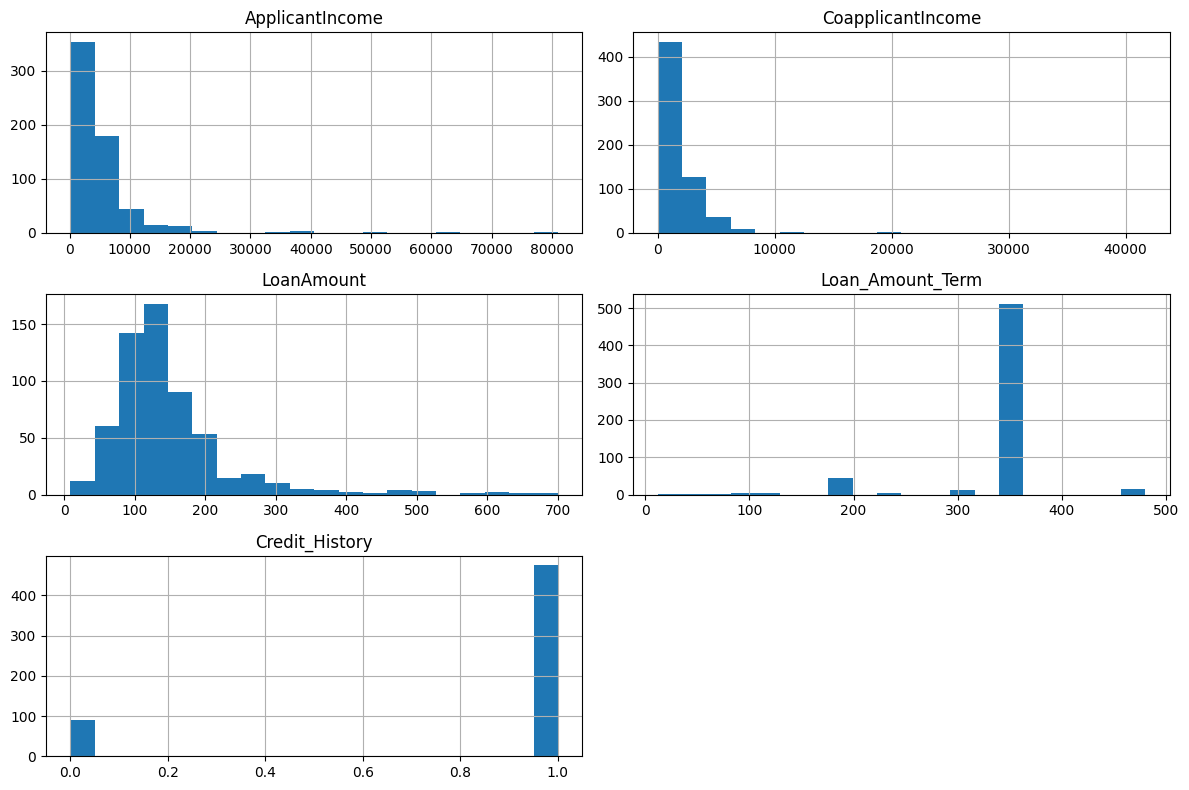

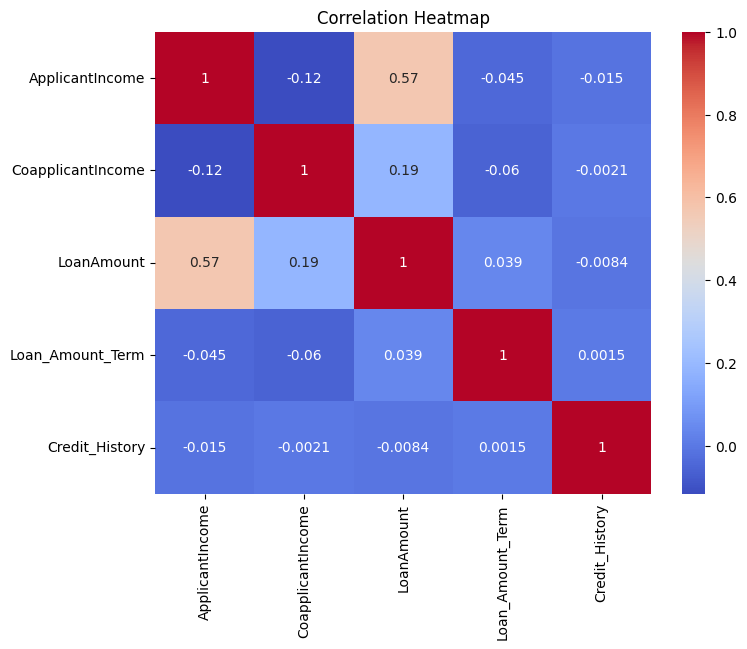

In [ ]:
df = pd.read_csv("../datasets/loan_prediction/train.csv")
a, b = eda_tabular(df)

Shape: (768, 9)

Column types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0

Summary statistics:
        Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218

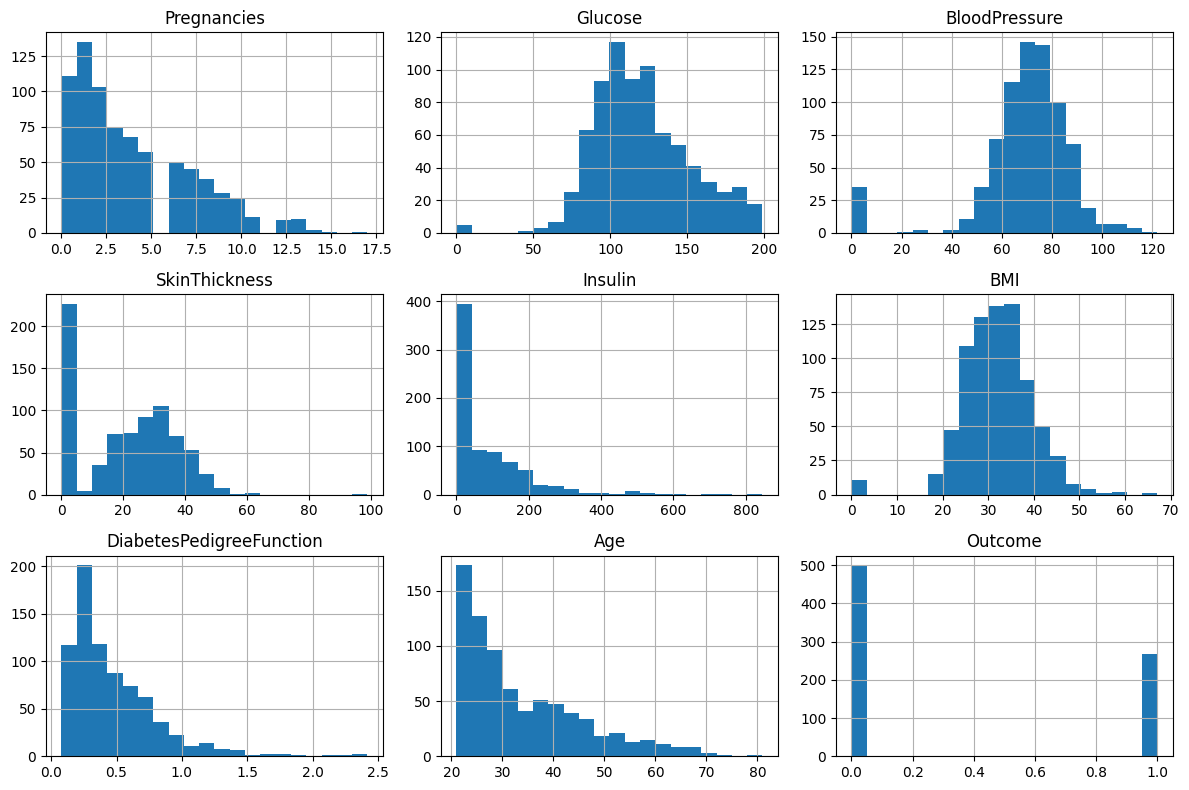

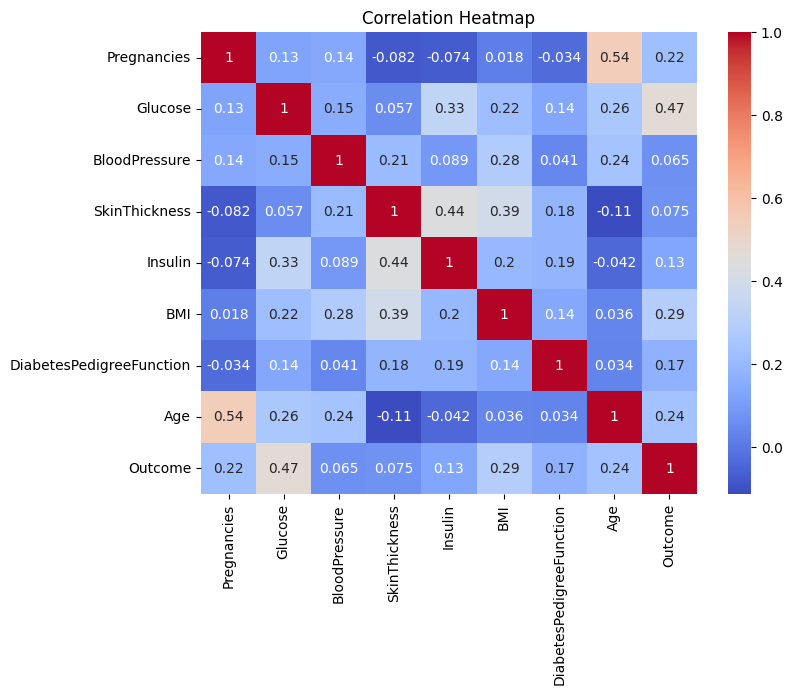

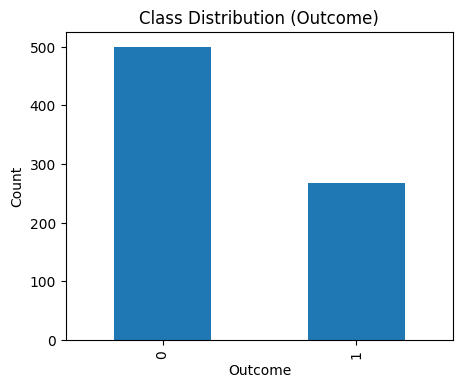

(Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
        'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
       dtype='str'),
 Index([], dtype='str'))

In [ ]:

df2 = pd.read_csv("../datasets/diabetes/diabetes.csv")
eda_tabular(df2, target = "Outcome")


Shape: (60000, 785)

First 5 Rows:
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]

Data Types:
int64    785
Name: count, dtype: int64

Missing Values:
0

Duplicate Rows:
0

Number of Images: 60000
Image Si

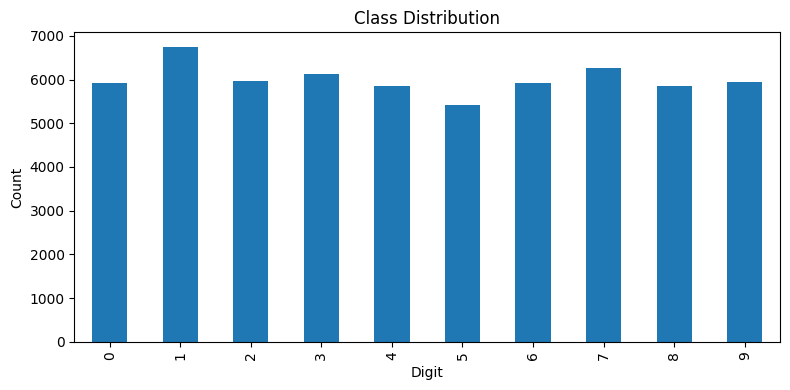

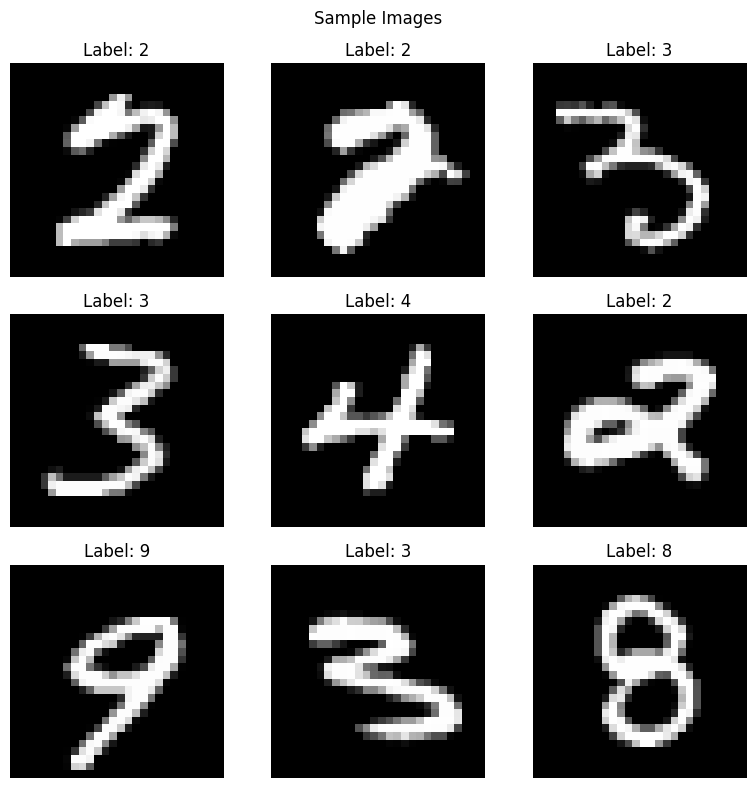

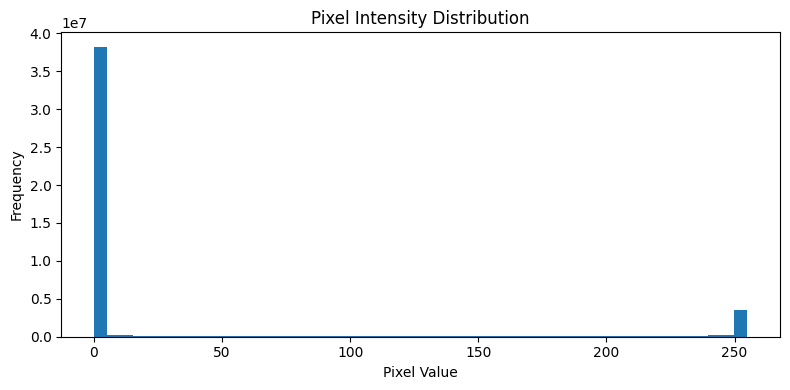

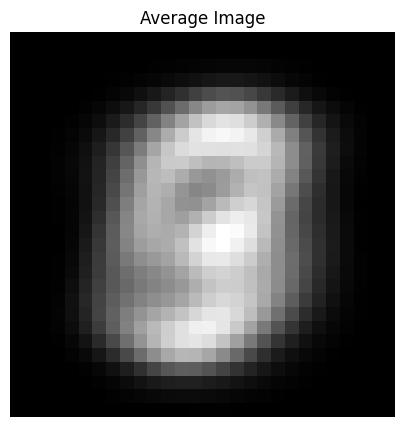


Pixel Statistics
-------------------------
Minimum Pixel : 0
Maximum Pixel : 255
Mean Pixel    : 33.32
Std Deviation : 78.57


In [29]:
df_img = pd.read_csv("../datasets/mnist_train.csv")
eda_images(df_img)